<a href="https://colab.research.google.com/github/IvanMoreno-utec/etl-data-pipeline2500292020/blob/main/Parcial4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
urlagr="https://raw.githubusercontent.com/IvanMoreno-utec/etl-data-pipeline2500292020/refs/heads/main/carpeta%20parcial%204/clave_H_agrupacion.csv"
urlaso="https://raw.githubusercontent.com/IvanMoreno-utec/etl-data-pipeline2500292020/refs/heads/main/carpeta%20parcial%204/clave_H_asociacion.csv"
urlcor="https://raw.githubusercontent.com/IvanMoreno-utec/etl-data-pipeline2500292020/refs/heads/main/carpeta%20parcial%204/clave_H_correlacion.csv"


In [4]:
import pandas as pd
import os

df_asociacion = pd.read_csv(urlaso)
df_agrupacion = pd.read_csv(urlagr)
df_correlacion = pd.read_csv(urlcor)

In [5]:
display(df_asociacion)


,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,H-T0001,H-C0026,2026-04-10,Cloud,Backup_cloud,2,Web
1,H-T0001,H-C0026,2026-04-10,Productividad,CRM,2,Web
2,H-T0001,H-C0026,2026-04-10,Educacion,Certificacion,1,Web
3,H-T0001,H-C0026,2026-04-10,Productividad,Notas,1,Web
4,H-T0002,H-C0038,2026-03-16,Productividad,CRM,1,Tienda
...,...,...,...,...,...,...,...
619,H-T0200,H-C0060,2026-01-13,Cloud,Backup_cloud,1,Tienda
620,H-T0200,H-C0060,2026-01-13,Educacion,Certificacion,1,Tienda
621,H-T0200,H-C0060,2026-01-13,Cloud,Hosting,2,Tienda
622,H-T0200,H-C0060,2026-01-13,Seguridad,VPN,1,Tienda


La información del csv asociación es un registro de compras en articulos de tech ya sea en fisico por canal tienda o web con su respectivo historial por fechas

In [6]:
def verificar_calidad(df, nombre):
    print(f"--- Análisis de: {nombre} ---")
    print("\n1. Información y Tipos de Datos:")
    print(df.info())
    print("\n2. Valores Nulos per columna:")
    print(df.isnull().sum())
    print(f"\n3. Cantidad de filas duplicadas: {df.duplicated().sum()}")
    print("\n" + "="*40 + "\n")

verificar_calidad(df_asociacion, "df_asociacion")

--- Análisis de: df_asociacion ---

1. Información y Tipos de Datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 624 entries, 0 to 623
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  624 non-null    object
 1   cliente_id      624 non-null    object
 2   fecha           624 non-null    object
 3   categoria       624 non-null    object
 4   item            624 non-null    object
 5   cantidad        624 non-null    int64 
 6   canal           623 non-null    object
dtypes: int64(1), object(6)
memory usage: 34.3+ KB
None

2. Valores Nulos per columna:
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64

3. Cantidad de filas duplicadas: 1




En el analisis no se econtro mas que un duplicado que se tomo como nulo fuera de eso la información en lo que cabe es consisa

In [7]:
#crear la matriz
basket = (df_asociacion.groupby(['transaccion_id', 'item'])['cantidad']
          .sum().unstack().reset_index().fillna(0)
          .set_index('transaccion_id'))

#valores a formato booleano (1 si el item está en la transacción, 0 si no)
def encode_units(x):
    if x <= 0:
        return False
    if x >= 1:
        return True

basket_sets = basket.applymap(encode_units)

print("Dimensiones de la matriz de transacciones:", basket_sets.shape)
print("\nPrimeras filas del formato preparado:")
display(basket_sets.head())

Dimensiones de la matriz de transacciones: (200, 20)

Primeras filas del formato preparado:


/tmp/ipykernel_25928/899061807.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_units)


item,Agenda,Almacenamiento,Antivirus,Backup_cloud,CRM,Certificacion,Colaboracion,Curso_excel,Curso_ingles,Curso_python,Dominio,Gestor_password,Hosting,Monitoreo,Notas,Plan_deportes,Plan_familiar,Plan_musica,Plan_video,VPN
transaccion_id,,,,,,,,,,,,,,,,,,,,
H-T0001,False,False,False,True,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False
H-T0002,False,False,False,False,True,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False
H-T0003,False,True,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False
H-T0004,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False
H-T0005,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True


de esta manera se que compra tiene que objeto indiferente de su fecha para el caso en caso de querer saber la fecha tengo que aplicarlo a la canasta o basket

In [10]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

#ítems frecuentes
frequent_itemsets = apriori(basket_sets, min_support=0.03, use_colnames=True)

#reglas de asociación
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

#ordenadas lift
reglas_finales = rules[rules['confidence'] >= 0.4].sort_values('lift', ascending=False)

print(f"Se han generado {len(reglas_finales)} reglas significativas.")
display(reglas_finales[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Se han generado 18 reglas significativas.


,antecedents,consequents,support,confidence,lift
77,"(Plan_familiar, VPN)",(Plan_video),0.040,0.888889,3.354298
65,"(Certificacion, Colaboracion)",(Curso_python),0.030,0.750000,3.125000
78,"(Plan_video, VPN)",(Plan_familiar),0.040,0.666667,3.100775
70,"(Certificacion, Plan_video)",(Curso_python),0.040,0.727273,3.030303
66,"(Curso_python, Colaboracion)",(Certificacion),0.030,0.750000,2.941176
52,(Gestor_password),(VPN),0.125,0.641026,2.616431
53,(VPN),(Gestor_password),0.125,0.510204,2.616431
46,(Dominio),(Hosting),0.105,0.567568,2.522523
47,(Hosting),(Dominio),0.105,0.466667,2.522523
63,(Plan_video),(Plan_familiar),0.140,0.528302,2.457218


In [11]:
#valor de lift
top_10_relevantes = reglas_finales.head(10)

print("Top 10 Reglas de Asociación más relevantes:")
display(top_10_relevantes[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Top 10 Reglas de Asociación más relevantes:


,antecedents,consequents,support,confidence,lift
77,"(Plan_familiar, VPN)",(Plan_video),0.040,0.888889,3.354298
65,"(Certificacion, Colaboracion)",(Curso_python),0.030,0.750000,3.125000
78,"(Plan_video, VPN)",(Plan_familiar),0.040,0.666667,3.100775
70,"(Certificacion, Plan_video)",(Curso_python),0.040,0.727273,3.030303
66,"(Curso_python, Colaboracion)",(Certificacion),0.030,0.750000,2.941176
52,(Gestor_password),(VPN),0.125,0.641026,2.616431
53,(VPN),(Gestor_password),0.125,0.510204,2.616431
46,(Dominio),(Hosting),0.105,0.567568,2.522523
47,(Hosting),(Dominio),0.105,0.466667,2.522523
63,(Plan_video),(Plan_familiar),0.140,0.528302,2.457218


In [13]:
display(df_correlacion)

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,H-C0001,53,867,5,53.63,8.09,2,3,18.49,296.27
1,H-C0002,31,1134,7,68.46,9.43,0,5,29.04,466.41
2,H-C0003,58,1635,5,81.71,5.95,4,3,20.85,399.02
3,H-C0004,38,1185,9,77.26,6.91,3,7,23.43,615.29
4,H-C0005,49,1276,11,88.71,8.34,0,9,8.20,914.97
...,...,...,...,...,...,...,...,...,...,...
251,H-C0252,43,1277,9,75.79,6.24,3,8,22.91,653.09
252,H-C0253,40,1354,34,87.86,7.73,1,5,18.14,2389.79
253,H-C0254,41,937,33,58.35,6.44,2,9,21.53,1540.44
254,H-C0255,26,1038,32,62.80,8.47,0,3,20.92,1607.68


In [15]:
print("\nVariables numéricas en df_correlacion:")
print(df_correlacion.select_dtypes(include=['number']).columns.tolist())


Variables numéricas en df_correlacion:
['edad', 'ingresos_mensuales', 'frecuencia_compra', 'ticket_promedio', 'satisfaccion', 'reclamos', 'uso_app', 'tiempo_respuesta', 'consumo_total']


In [16]:
print("\n--- Revisión de df_correlacion ---")
verificar_calidad(df_correlacion, "df_correlacion")

print("\nEstadísticas descriptivas (posibles atípicos) para df_correlacion:")
display(df_correlacion.select_dtypes(include=['number']).describe())

print("\nValores únicos para columnas categóricas en df_correlacion (consistencia):")
for col in df_correlacion.select_dtypes(include=['object']).columns:
    print(f"  {col}: {df_correlacion[col].nunique()} únicos: {df_correlacion[col].unique()}")



--- Revisión de df_correlacion ---
--- Análisis de: df_correlacion ---

1. Información y Tipos de Datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          256 non-null    object 
 1   edad                256 non-null    int64  
 2   ingresos_mensuales  256 non-null    int64  
 3   frecuencia_compra   256 non-null    int64  
 4   ticket_promedio     255 non-null    float64
 5   satisfaccion        255 non-null    float64
 6   reclamos            256 non-null    int64  
 7   uso_app             256 non-null    int64  
 8   tiempo_respuesta    255 non-null    float64
 9   consumo_total       256 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 20.1+ KB
None

2. Valores Nulos per columna:
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,256.000000,256.000000,256.000000,255.00000,255.000000,256.000000,256.000000,255.000000,256.000000
mean,41.816406,1238.472656,8.070312,72.85400,7.560667,1.550781,5.871094,21.359843,569.450977
std,10.051704,248.618408,3.430391,14.43644,1.262785,1.533086,2.004648,5.630791,225.011440
min,18.000000,619.000000,2.000000,27.97000,2.540000,0.000000,1.000000,7.200000,183.240000
25%,35.000000,1059.250000,6.000000,63.32500,6.845000,1.000000,5.000000,18.205000,444.872500
50%,41.000000,1236.500000,8.000000,72.72000,7.760000,1.000000,6.000000,21.190000,551.300000
75%,48.000000,1407.250000,9.000000,82.97500,8.365000,2.000000,7.000000,25.010000,659.382500
max,68.000000,1899.000000,34.000000,128.77000,9.830000,9.000000,10.000000,40.420000,2389.790000



Valores únicos para columnas categóricas en df_correlacion (consistencia):
  cliente_id: 255 únicos: ['H-C0001' 'H-C0002' 'H-C0003' 'H-C0004' 'H-C0005' 'H-C0006' 'H-C0007'
 'H-C0008' 'H-C0009' 'H-C0010' 'H-C0011' 'H-C0012' 'H-C0013' 'H-C0014'
 'H-C0015' 'H-C0016' 'H-C0017' 'H-C0018' 'H-C0019' 'H-C0020' 'H-C0021'
 'H-C0022' 'H-C0023' 'H-C0024' 'H-C0025' 'H-C0026' 'H-C0027' 'H-C0028'
 'H-C0029' 'H-C0030' 'H-C0031' 'H-C0032' 'H-C0033' 'H-C0034' 'H-C0035'
 'H-C0036' 'H-C0037' 'H-C0038' 'H-C0039' 'H-C0040' 'H-C0041' 'H-C0042'
 'H-C0043' 'H-C0044' 'H-C0045' 'H-C0046' 'H-C0047' 'H-C0048' 'H-C0049'
 'H-C0050' 'H-C0051' 'H-C0052' 'H-C0053' 'H-C0054' 'H-C0055' 'H-C0056'
 'H-C0057' 'H-C0058' 'H-C0059' 'H-C0060' 'H-C0061' 'H-C0062' 'H-C0063'
 'H-C0064' 'H-C0065' 'H-C0066' 'H-C0067' 'H-C0068' 'H-C0069' 'H-C0070'
 'H-C0071' 'H-C0072' 'H-C0073' 'H-C0074' 'H-C0075' 'H-C0076' 'H-C0077'
 'H-C0078' 'H-C0079' 'H-C0080' 'H-C0081' 'H-C0082' 'H-C0083' 'H-C0084'
 'H-C0085' 'H-C0086' 'H-C0087' 'H-C0088' 'H-C0

In [17]:
df_correlacion_numerico = df_correlacion.select_dtypes(include=['number'])
matriz_correlacion = df_correlacion_numerico.corr()

print("Matriz de Correlación para df_correlacion:")
display(matriz_correlacion)

Matriz de Correlación para df_correlacion:


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000000,0.016661,-0.000307,0.150597,0.008511,0.027201,0.116954,-0.063155,0.067152
ingresos_mensuales,0.016661,1.000000,0.051051,0.568912,-0.014222,0.054986,-0.068167,-0.041842,0.292867
frecuencia_compra,-0.000307,0.051051,1.000000,0.038058,0.152668,-0.111787,0.439858,-0.216890,0.879637
ticket_promedio,0.150597,0.568912,0.038058,1.000000,0.056423,-0.039127,-0.026956,-0.038734,0.430907
satisfaccion,0.008511,-0.014222,0.152668,0.056423,1.000000,-0.799622,0.178477,-0.542621,0.262528
reclamos,0.027201,0.054986,-0.111787,-0.039127,-0.799622,1.000000,0.012984,0.473224,-0.211259
uso_app,0.116954,-0.068167,0.439858,-0.026956,0.178477,0.012984,1.000000,-0.324614,0.458099
tiempo_respuesta,-0.063155,-0.041842,-0.216890,-0.038734,-0.542621,0.473224,-0.324614,1.000000,-0.308279
consumo_total,0.067152,0.292867,0.879637,0.430907,0.262528,-0.211259,0.458099,-0.308279,1.000000


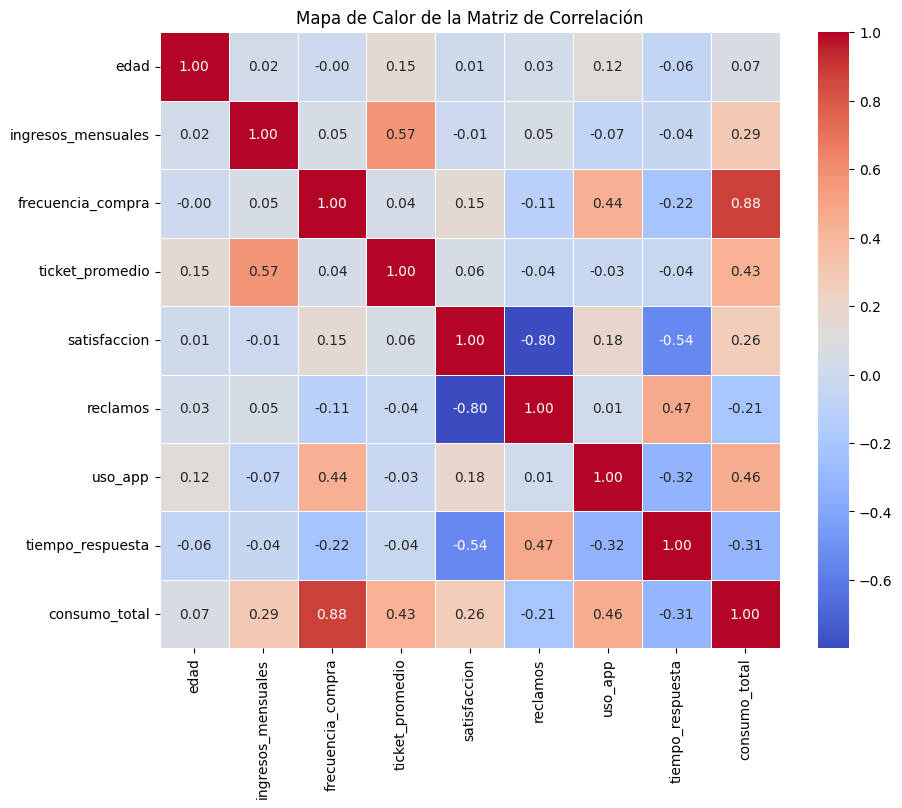

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

In [19]:
correlaciones_positivas = matriz_correlacion.unstack()
correlaciones_positivas = correlaciones_positivas[correlaciones_positivas > 0].drop_duplicates()
correlaciones_positivas = correlaciones_positivas[correlaciones_positivas < 1]

correlaciones_positivas = correlaciones_positivas.sort_values(ascending=False)

print("Correlaciones Positivas Más Importantes:")
display(correlaciones_positivas.head(10))

Correlaciones Positivas Más Importantes:


frecuencia_compra   consumo_total       0.879637
ingresos_mensuales  ticket_promedio     0.568912
reclamos            tiempo_respuesta    0.473224
uso_app             consumo_total       0.458099
frecuencia_compra   uso_app             0.439858
ticket_promedio     consumo_total       0.430907
ingresos_mensuales  consumo_total       0.292867
satisfaccion        consumo_total       0.262528
                    uso_app             0.178477
frecuencia_compra   satisfaccion        0.152668
dtype: float64

In [20]:
correlaciones_negativas = matriz_correlacion.unstack()
correlaciones_negativas = correlaciones_negativas[correlaciones_negativas < 0].drop_duplicates()

correlaciones_negativas = correlaciones_negativas.sort_values(ascending=True)

print("Correlaciones Negativas Más Importantes:")
display(correlaciones_negativas.head(10))

Correlaciones Negativas Más Importantes:


satisfaccion        reclamos           -0.799622
                    tiempo_respuesta   -0.542621
uso_app             tiempo_respuesta   -0.324614
tiempo_respuesta    consumo_total      -0.308279
frecuencia_compra   tiempo_respuesta   -0.216890
reclamos            consumo_total      -0.211259
frecuencia_compra   reclamos           -0.111787
ingresos_mensuales  uso_app            -0.068167
edad                tiempo_respuesta   -0.063155
ingresos_mensuales  tiempo_respuesta   -0.041842
dtype: float64

In [21]:

display(df_agrupacion)

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,H-R0158,48,1292,9.60,158.47,8.45,0,37
1,H-R0209,39,707,6.72,73.85,2.99,6,1
2,H-R0257,37,1100,4.02,79.86,3.68,4,4
3,H-R0037,35,582,3.25,44.88,5.18,12,8
4,H-R0132,37,1191,6.66,55.80,7.96,1,23
...,...,...,...,...,...,...,...,...
253,H-R0029,34,900,2.34,34.61,5.28,5,1
254,H-R0200,62,1711,6.35,148.22,8.39,1,27
255,H-R0215,45,774,0.01,66.41,4.23,4,16
256,H-R0031,33,780,1.93,45.16,6.14,4,1


In [22]:
variables_clustering_agrupacion = ['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos']
df_clustering_agrupacion = df_agrupacion[variables_clustering_agrupacion].copy()

print("Primeras filas del DataFrame preparado para clustering de df_agrupacion:")
display(df_clustering_agrupacion.head())

print("\nValores nulos en el DataFrame de clustering de df_agrupacion (antes del tratamiento):")
print(df_clustering_agrupacion.isnull().sum())

Primeras filas del DataFrame preparado para clustering de df_agrupacion:


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos
0,48,1292,9.60,158.47,8.45,0
1,39,707,6.72,73.85,2.99,6
2,37,1100,4.02,79.86,3.68,4
3,35,582,3.25,44.88,5.18,12
4,37,1191,6.66,55.80,7.96,1



Valores nulos en el DataFrame de clustering de df_agrupacion (antes del tratamiento):
edad              0
ingresos          0
frecuencia_uso    0
gasto_promedio    0
satisfaccion      1
reclamos          0
dtype: int64
